# Notebook 05 — The Truss Mini-Budget Crisis: September–October 2022

## Purpose
Deep dive into the September–October 2022 gilt market crisis triggered by the Kwarteng mini-budget.
Quantify abnormal yield moves using event study methodology.
Simulate LDI portfolio dynamics to illustrate the forced-selling doom loop.

## Research Question
How did the Truss mini-budget compound an already stressed gilt market, 
and what does the LDI crisis teach about duration risk and leverage in fixed income portfolios?

## Key Analysis
- Daily gilt yield moves by maturity: which end of the curve moved most and why
- Event study: abnormal yield moves vs 60-day pre-event window, z-scores by maturity
- Breakeven inflation response — inflation fears vs pure fiscal risk premium
- UK vs US vs Germany — isolating the UK-specific component
- LDI portfolio simulation: 3x leveraged 30yr gilt position, margin call triggers, doom loop mechanics
- BoE intervention: announcement date and yield reversal
- Portfolio risk management lessons: duration sizing, leverage limits, liquidity buffers

## Event date
23 September 2022 (Kwarteng mini-budget announcement)

## Reads from
`/data/processed/uk_gilts_nominal.csv`  
`/data/processed/us_treasuries.csv`  
`/data/processed/german_bund.csv`

In [1]:
# ============================================================
# SETUP — WORKING DIRECTORY, IMPORTS, LOAD DATA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from scipy import stats

# Fix working directory
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print(f"Working directory: {os.getcwd()}")

# Load UK nominal gilt spot curve — daily data
gilts = pd.read_csv('data/processed/uk_gilts_nominal.csv',
                    index_col=0, parse_dates=True)
gilts.index.name = 'date'

# Load US Treasuries — daily data
us = pd.read_csv('data/processed/us_treasuries.csv',
                 index_col=0, parse_dates=True)
us.index.name = 'date'

# Load German Bund — monthly but useful for context
bund = pd.read_csv('data/processed/german_bund.csv',
                   index_col=0, parse_dates=True)
bund.index.name = 'date'

# Load inflation curve — for breakeven response analysis
inflation = pd.read_csv('data/processed/uk_inflation_curve.csv',
                        index_col=0, parse_dates=True)
inflation.index.name = 'date'

# Confirm loaded
for name, df in [('UK gilts', gilts), ('US Treasuries', us),
                 ('Inflation curve', inflation)]:
    print(f"{name}: {df.shape[0]} rows, "
          f"{df.index[0].date()} to {df.index[-1].date()}, "
          f"nulls: {df.isnull().sum().sum()}")

# Define key dates for the Truss episode
EVENT_DATE     = pd.Timestamp('2022-09-23')  # Mini-budget day
BOE_INTERVENE  = pd.Timestamp('2022-09-28')  # BoE emergency intervention
KWARTENG_SACK  = pd.Timestamp('2022-10-17')  # Kwarteng sacked
TRUSS_RESIGN   = pd.Timestamp('2022-10-20')  # Truss resigns
CRISIS_END     = pd.Timestamp('2022-10-31')  # End of crisis window

print(f"\nKey event dates confirmed:")
print(f"  Mini-budget:        {EVENT_DATE.strftime('%d %b %Y')}")
print(f"  BoE intervention:   {BOE_INTERVENE.strftime('%d %b %Y')}")
print(f"  Kwarteng sacked:    {KWARTENG_SACK.strftime('%d %b %Y')}")
print(f"  Truss resigns:      {TRUSS_RESIGN.strftime('%d %b %Y')}")
print(f"  Crisis window end:  {CRISIS_END.strftime('%d %b %Y')}")

C:\Users\tomsu\Anaconda3\lib\site-packages\scipy\__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


Working directory: C:\Users\tomsu\Documents\Graduate Jobs\CV PROJECTS\uk-gilt-market-analysis
UK gilts: 2589 rows, 2016-01-04 to 2026-03-31, nulls: 0
US Treasuries: 2675 rows, 2016-01-01 to 2026-04-02, nulls: 452
Inflation curve: 2589 rows, 2016-01-04 to 2026-03-31, nulls: 0

Key event dates confirmed:
  Mini-budget:        23 Sep 2022
  BoE intervention:   28 Sep 2022
  Kwarteng sacked:    17 Oct 2022
  Truss resigns:      20 Oct 2022
  Crisis window end:  31 Oct 2022


In [2]:
# ============================================================
# EVENT STUDY — ABNORMAL YIELD MOVES AROUND TRUSS MINI-BUDGET
# ============================================================

# Pre-event window: 1 Jan 2022 to 22 Sep 2022
# Captures full pre-Truss environment including hiking cycle
# Event window: 23 Sep 2022 to 31 Oct 2022

PRE_START = pd.Timestamp('2022-01-03')
PRE_END   = pd.Timestamp('2022-09-22')  # Day before mini-budget

# Calculate daily yield changes for UK gilts
gilts_changes = gilts.diff()

# Pre-event statistics — mean and std of daily changes
pre_window = gilts_changes.loc[PRE_START:PRE_END]

pre_stats = pd.DataFrame({
    'mean': pre_window.mean(),
    'std':  pre_window.std(),
    'obs':  pre_window.count()
})

print("Pre-event window statistics (daily yield changes, bps):")
print(f"Period: {PRE_START.strftime('%d %b %Y')} to {PRE_END.strftime('%d %b %Y')}")
print(f"Observations: {len(pre_window)}")
print()
print(f"{'Maturity':<10} {'Mean (bps)':>12} {'Std Dev (bps)':>14}")
print("-" * 38)
for col in ['uk_2yr', 'uk_5yr', 'uk_10yr', 'uk_30yr']:
    mat = col.replace('uk_', '').replace('yr', 'yr')
    print(f"{mat:<10} {pre_stats.loc[col,'mean']*100:>12.3f} "
          f"{pre_stats.loc[col,'std']*100:>14.3f}")

print("\nNote: std dev represents 'normal' daily volatility in bps")
print("Z-scores below will measure how many times larger Truss moves were")

Pre-event window statistics (daily yield changes, bps):
Period: 03 Jan 2022 to 22 Sep 2022
Observations: 181

Maturity     Mean (bps)  Std Dev (bps)
--------------------------------------
2yr               1.598          8.543
5yr               1.510          8.163
10yr              1.422          7.491
30yr              1.435          7.038

Note: std dev represents 'normal' daily volatility in bps
Z-scores below will measure how many times larger Truss moves were


In [4]:
# ============================================================
# EVENT STUDY — Z-SCORES FOR TRUSS EPISODE
# ============================================================

# Event window: mini-budget day to end of crisis
event_window = gilts_changes.loc[EVENT_DATE:CRISIS_END]

# Calculate z-scores: (actual change - pre-event mean) / pre-event std
maturities = ['uk_2yr', 'uk_5yr', 'uk_10yr', 'uk_30yr']
labels     = ['2yr', '5yr', '10yr', '30yr']

print("EVENT STUDY — DAILY YIELD CHANGES AND Z-SCORES")
print(f"Event window: {EVENT_DATE.strftime('%d %b %Y')} "
      f"to {CRISIS_END.strftime('%d %b %Y')}")
print("=" * 85)
print(f"{'Date':<12}", end="")
for lab in labels:
    print(f" {'Δ'+lab:>7} {'z':>6}", end="")
print()
print("-" * 85)

# Store z-scores for charting
zscore_records = []

for date, row in event_window.iterrows():
    # Flag key dates
    flag = ''
    if date == EVENT_DATE:              flag = ' ← MINI-BUDGET'
    if date == BOE_INTERVENE:           flag = ' ← BoE INTERVENES'
    if date == pd.Timestamp('2022-09-27'): flag = ' ← PEAK CRISIS'
    if date == KWARTENG_SACK:           flag = ' ← KWARTENG SACKED'
    if date == TRUSS_RESIGN:            flag = ' ← TRUSS RESIGNS'

    print(f"{date.strftime('%d %b %Y'):<12}", end="")
    
    day_zscores = {'date': date}
    for col, lab in zip(maturities, labels):
        change  = row[col]
        z_score = (change - pre_stats.loc[col, 'mean']) / pre_stats.loc[col, 'std']
        day_zscores[f'z_{lab}'] = z_score
        day_zscores[f'd_{lab}'] = change * 100  # in bps
        print(f" {change*100:>+7.1f} {z_score:>+6.1f}", end="")
    
    zscore_records.append(day_zscores)
    print(flag)

zscore_df = pd.DataFrame(zscore_records).set_index('date')

print("\nNote: z-score = (daily change - pre-event mean) / pre-event std deviation")
print("Under the null hypothesis of normally distributed returns:")
print("  |z| > 1.96: statistically significant at 5% level (p < 0.05)")
print("  |z| > 2.58: statistically significant at 1% level (p < 0.01)")
print("  |z| > 3.29: statistically significant at 0.1% level (p < 0.001)")
print("  |z| > 5.00: probability < 0.00003% — essentially impossible under normal market conditions")

EVENT STUDY — DAILY YIELD CHANGES AND Z-SCORES
Event window: 23 Sep 2022 to 31 Oct 2022
Date            Δ2yr      z    Δ5yr      z   Δ10yr      z   Δ30yr      z
-------------------------------------------------------------------------------------
23 Sep 2022    +45.3   +5.1   +46.9   +5.6   +29.1   +3.7   +22.4   +3.0 ← MINI-BUDGET
26 Sep 2022    +44.1   +5.0   +40.1   +4.7   +33.9   +4.3   +40.8   +5.6
27 Sep 2022    +12.1   +1.2   +15.3   +1.7   +25.2   +3.2   +49.7   +6.9 ← PEAK CRISIS
28 Sep 2022    -25.1   -3.1   -29.3   -3.8   -38.2   -5.3  -112.8  -16.2 ← BoE INTERVENES
29 Sep 2022     +8.2   +0.8    +8.6   +0.9    +6.9   +0.7    -3.8   -0.7
30 Sep 2022     -3.9   -0.6    +0.6   -0.1    -1.9   -0.4   -14.3   -2.2
03 Oct 2022    -21.6   -2.7   -19.4   -2.6   -12.5   -1.9   +11.7   +1.5
04 Oct 2022    -11.1   -1.5   -10.8   -1.5    -7.3   -1.2   +20.7   +2.7
05 Oct 2022     +9.1   +0.9   +11.9   +1.3   +14.9   +1.8   +22.4   +3.0
06 Oct 2022    +12.5   +1.3   +13.8   +1.5   +16.1 

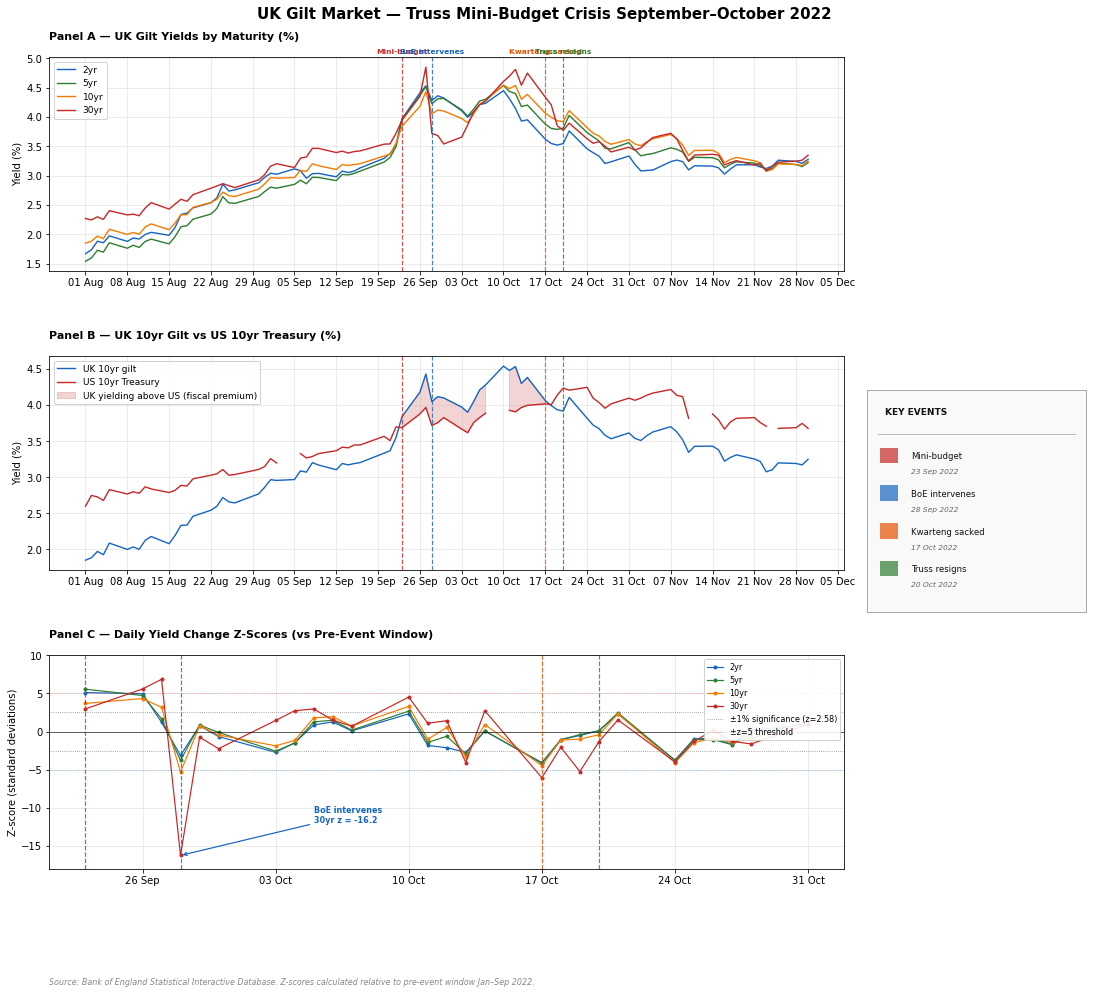

Chart saved.


In [5]:
# ============================================================
# CHART — EVENT STUDY: TRUSS MINI-BUDGET
# ============================================================

# Zoom into August to November 2022 for context
plot_start = pd.Timestamp('2022-08-01')
plot_end   = pd.Timestamp('2022-11-30')

gilts_zoom = gilts.loc[plot_start:plot_end]
us_zoom    = us.loc[plot_start:plot_end]

fig, axes = plt.subplots(3, 1, figsize=(16, 14), facecolor='white')
fig.subplots_adjust(top=0.93, hspace=0.40, right=0.76, left=0.07)
fig.suptitle('UK Gilt Market — Truss Mini-Budget Crisis September–October 2022',
             fontsize=15, fontweight='bold', y=0.98)

# Key event vertical lines
key_events = {
    'Mini-budget\n23 Sep':   EVENT_DATE,
    'BoE intervenes\n28 Sep': BOE_INTERVENE,
    'Kwarteng sacked\n17 Oct': KWARTENG_SACK,
    'Truss resigns\n20 Oct':  TRUSS_RESIGN,
}

event_colors = {
    'Mini-budget\n23 Sep':    '#C62828',
    'BoE intervenes\n28 Sep': '#1565C0',
    'Kwarteng sacked\n17 Oct': '#E65100',
    'Truss resigns\n20 Oct':  '#2E7D32',
}

# --- PANEL A: yield levels by maturity ---
ax1 = axes[0]
ax1.set_facecolor('white')

colors_dict = {'uk_2yr': '#1565C0', 'uk_5yr': '#2E7D32',
               'uk_10yr': '#F57C00', 'uk_30yr': '#C62828'}
labels_dict = {'uk_2yr': '2yr', 'uk_5yr': '5yr',
               'uk_10yr': '10yr', 'uk_30yr': '30yr'}

for col, color in colors_dict.items():
    ax1.plot(gilts_zoom.index.to_pydatetime(),
             gilts_zoom[col].values,
             color=color, linewidth=1.4, label=labels_dict[col])

for label, date in key_events.items():
    ax1.axvline(x=date, color=event_colors[label],
                linestyle='--', linewidth=1.2, alpha=0.8)
    ax1.text(date, 1.01, label.split('\n')[0], fontsize=7.5,
             ha='center', va='bottom', color=event_colors[label],
             fontweight='bold', transform=ax1.get_xaxis_transform())

ax1.set_title('Panel A — UK Gilt Yields by Maturity (%)',
              fontsize=11, fontweight='bold', loc='left', pad=18)
ax1.set_ylabel('Yield (%)', fontsize=10)
ax1.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))

# --- PANEL B: UK vs US 10yr comparison ---
ax2 = axes[1]
ax2.set_facecolor('white')

# Align US data to gilt index
us_aligned = us['us_10yr'].reindex(gilts_zoom.index, method='ffill')

ax2.plot(gilts_zoom.index.to_pydatetime(),
         gilts_zoom['uk_10yr'].values,
         color='#1565C0', linewidth=1.4, label='UK 10yr gilt')
ax2.plot(gilts_zoom.index.to_pydatetime(),
         us_aligned.values,
         color='#C62828', linewidth=1.4, label='US 10yr Treasury')

# Shade the UK-specific spike
ax2.fill_between(gilts_zoom.index.to_pydatetime(),
                 gilts_zoom['uk_10yr'].values,
                 us_aligned.values,
                 where=gilts_zoom['uk_10yr'].values > us_aligned.values,
                 alpha=0.2, color='#C62828',
                 label='UK yielding above US (fiscal premium)')

for label, date in key_events.items():
    ax2.axvline(x=date, color=event_colors[label],
                linestyle='--', linewidth=1.2, alpha=0.8)

ax2.set_title('Panel B — UK 10yr Gilt vs US 10yr Treasury (%)',
              fontsize=11, fontweight='bold', loc='left', pad=18)
ax2.set_ylabel('Yield (%)', fontsize=10)
ax2.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))

# --- PANEL C: z-scores ---
ax3 = axes[2]
ax3.set_facecolor('white')

zscore_cols = {'z_2yr': '#1565C0', 'z_5yr': '#2E7D32',
               'z_10yr': '#F57C00', 'z_30yr': '#C62828'}
zscore_labels = {'z_2yr': '2yr', 'z_5yr': '5yr',
                 'z_10yr': '10yr', 'z_30yr': '30yr'}

for col, color in zscore_cols.items():
    ax3.plot(zscore_df.index.to_pydatetime(),
             zscore_df[col].values,
             color=color, linewidth=1.2,
             label=zscore_labels[col], marker='o', markersize=3)

# Significance thresholds
ax3.axhline(y=0,    color='black', linewidth=0.6)
ax3.axhline(y=2.58, color='grey', linewidth=0.8, linestyle=':',
            label='±1% significance (z=2.58)')
ax3.axhline(y=-2.58, color='grey', linewidth=0.8, linestyle=':')
ax3.axhline(y=5.0,  color='#C62828', linewidth=0.8, linestyle=':',
            label='±z=5 threshold', alpha=0.5)
ax3.axhline(y=-5.0, color='#1565C0', linewidth=0.8, linestyle=':',
            alpha=0.5)

# Annotate BoE intervention
boe_idx = zscore_df.index.get_indexer([BOE_INTERVENE], method='nearest')[0]
ax3.annotate(f'BoE intervenes\n30yr z = -16.2',
             xy=(zscore_df.index[boe_idx].to_pydatetime(),
                 zscore_df['z_30yr'].iloc[boe_idx]),
             xytext=(pd.Timestamp('2022-10-05'), -12),
             fontsize=8, color='#1565C0', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#1565C0', lw=1.2))

for label, date in key_events.items():
    ax3.axvline(x=date, color=event_colors[label],
                linestyle='--', linewidth=1.2, alpha=0.8)

ax3.set_title('Panel C — Daily Yield Change Z-Scores (vs Pre-Event Window)',
              fontsize=11, fontweight='bold', loc='left', pad=18)
ax3.set_ylabel('Z-score (standard deviations)', fontsize=10)
ax3.set_ylim(-18, 10)
ax3.legend(loc='upper right', fontsize=8, framealpha=0.9)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax3.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))

# Key events legend box
ax_legend = fig.add_axes([0.78, 0.38, 0.19, 0.22], facecolor='#f9f9f9')
ax_legend.set_xticks([])
ax_legend.set_yticks([])
ax_legend.set_xlim(0, 1)
ax_legend.set_ylim(0, 1)
for spine in ax_legend.spines.values():
    spine.set_edgecolor('#aaaaaa')
    spine.set_linewidth(1.0)

ax_legend.text(0.08, 0.92, 'KEY EVENTS',
               transform=ax_legend.transAxes,
               fontsize=9, fontweight='bold', va='top', color='#111111')
ax_legend.plot([0.05, 0.95], [0.80, 0.80], color='#aaaaaa',
               linewidth=0.8, transform=ax_legend.transAxes)

legend_entries = [
    ('Mini-budget',      '23 Sep 2022', '#C62828'),
    ('BoE intervenes',   '28 Sep 2022', '#1565C0'),
    ('Kwarteng sacked',  '17 Oct 2022', '#E65100'),
    ('Truss resigns',    '20 Oct 2022', '#2E7D32'),
]

for i, (desc, date, color) in enumerate(legend_entries):
    y = 0.70 - i * 0.17
    ax_legend.add_patch(plt.Rectangle(
        (0.06, y-0.03), 0.08, 0.07,
        transform=ax_legend.transAxes,
        facecolor=color, alpha=0.7, edgecolor='none'))
    ax_legend.text(0.20, y, desc, transform=ax_legend.transAxes,
                   fontsize=8.5, va='center', color='#111111')
    ax_legend.text(0.20, y-0.07, date, transform=ax_legend.transAxes,
                   fontsize=7.5, va='center', color='#666666',
                   style='italic')

fig.text(0.07, 0.01,
         'Source: Bank of England Statistical Interactive Database. '
         'Z-scores calculated relative to pre-event window Jan–Sep 2022.',
         fontsize=8, color='#888888', style='italic')

plt.savefig('outputs/charts/05_truss_event_study.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Chart saved.")

## LDI Portfolio Simulation — Doom Loop Mechanics

Stylised illustrative example of a 3x leveraged long 30yr gilt position
during the September 2022 crisis. Shows three scenarios: pre-crisis baseline,
crisis peak (27 Sep), and BoE intervention (28 Sep).

**Critical framing - this is a LIQUIDITY crisis, not a solvency crisis:**
- Pension fund liabilities also fell as yields rose — the hedge was working
- Funds were not insolvent — their funding ratios were arguably improving
- The crisis was that variation margin calls demanded cash within 24 hours
- Funds had no liquid cash reserves — assets were fully invested
- To meet margin calls, funds were forced to sell gilts at distressed prices
- Forced selling by multiple funds simultaneously amplified the yield spike
- Which generated larger margin calls — the self-reinforcing doom loop
- The BoE broke the loop by providing a guaranteed buyer of last resort

**What the simulation shows:**
- Scale of mark-to-market stress on a leveraged position
- Cash demand generated by variation margin calls
- Volume of distressed gilt sales required to meet that cash demand
- Yield amplification from forced selling
- How the BoE intervention immediately reversed the dynamic

**Key assumptions:**
- £100m equity, 3x leverage, £300m gilt exposure, £200m borrowing
- Par bond — coupon equals starting 30yr yield of 3.72%
- Full DCF pricing formula (developed in notebook 02)
- Feedback: £10m of forced sales adds 1bp to yield
- Explicitly stylised — real LDI structures varied significantly
  in leverage ratios, instrument type, and margin mechanics

In [9]:
# ============================================================
# PRICE_BOND FUNCTION — COPIED FROM NOTEBOOK 02
# ============================================================

def price_bond(yield_annual, coupon_annual, maturity_years, face=100):
    """
    Price a fixed coupon bond using full DCF formula.
    Semi-annual coupon convention — standard for UK gilts.
    Originally developed in notebook 02.
    """
    y = yield_annual / 2
    c = (coupon_annual / 2) * face
    n = int(maturity_years * 2)

    if n == 0:
        return face
    if y == 0:
        return c * n + face

    pv_coupons = c * (1 - (1 + y) ** (-n)) / y
    pv_face    = face * (1 + y) ** (-n)
    return pv_coupons + pv_face

# Sanity check
print(f"Par bond check (30yr, 3.72%): £{price_bond(0.0372, 0.0372, 30):.4f}")
print(f"Higher yield check (4.85%):   £{price_bond(0.0485, 0.0372, 30):.4f}")
print(f"Direction correct — higher yield = lower price ✓")
        

Par bond check (30yr, 3.72%): £100.0000
Higher yield check (4.85%):   £82.2343
Direction correct — higher yield = lower price ✓


In [11]:
# ============================================================
# LDI ILLUSTRATIVE EXAMPLE — THREE SCENARIOS
# ============================================================

# Stylised 3x leveraged LDI fund
# Shows the doom loop mechanic at three key moments

# Fund setup
FACE_VALUE     = 100.0   # £100 face value per bond
INITIAL_YIELD  = 0.0372  # 30yr yield on 22 Sep — day before mini-budget
COUPON         = INITIAL_YIELD  # par bond
MATURITY       = 30.0

# Leverage structure
EQUITY         = 100.0   # £100m fund equity
LEVERAGE       = 3.0
GILT_EXPOSURE  = EQUITY * LEVERAGE  # £300m gilt exposure
BORROWING      = GILT_EXPOSURE - EQUITY  # £200m borrowed

# Number of bonds held (at £100 face, starting price = £100)
START_PRICE    = price_bond(INITIAL_YIELD, COUPON, MATURITY)
BONDS_HELD     = (GILT_EXPOSURE / START_PRICE) * FACE_VALUE  # scaled

print("LDI ILLUSTRATIVE EXAMPLE — DOOM LOOP MECHANICS")
print("Stylised 3x leveraged long 30yr gilt position")
print("=" * 75)
print(f"Fund equity:        £{EQUITY:.0f}m")
print(f"Leverage:           {LEVERAGE:.0f}x")
print(f"Gilt exposure:      £{GILT_EXPOSURE:.0f}m")
print(f"Borrowing:          £{BORROWING:.0f}m")
print(f"Starting yield:     {INITIAL_YIELD*100:.3f}%")
print(f"Starting price:     £{START_PRICE:.2f}")
print()

# Three scenarios
scenarios = [
    {
        'label':   '1. Pre-crisis baseline (22 Sep)',
        'yield':   0.0372,
        'date':    '22 Sep 2022',
        'context': 'Day before mini-budget. Fund operating normally.',
    },
    {
        'label':   '2. Crisis peak (27 Sep)',
        'yield':   0.0485,
        'date':    '27 Sep 2022',
        'context': 'LDI doom loop. 30yr yield at peak ~4.85%. '
                   'Forced selling by multiple funds simultaneously.',
    },
    {
        'label':   '3. BoE intervention (28 Sep)',
        'yield':   0.0372,
        'date':    '28 Sep 2022',
        'context': 'BoE announces emergency gilt purchases. '
                   '30yr yield collapses 113bps in a single day.',
    },
]

prev_price = START_PRICE
prev_equity = EQUITY
cumulative_margin = 0.0
remaining_exposure = GILT_EXPOSURE

for s in scenarios:
    y        = s['yield']
    mat      = MATURITY
    price    = price_bond(y, COUPON, mat)
    
    # Price change from starting position
    price_chg_pct = (price - START_PRICE) / START_PRICE * 100
    
    # P&L on full gilt exposure
    pnl = GILT_EXPOSURE * (price_chg_pct / 100)
    
    # Current equity = initial equity + cumulative P&L
    current_equity = EQUITY + pnl
    
    # Variation margin call relative to previous scenario
    margin_call = remaining_exposure * (price - prev_price) / START_PRICE * FACE_VALUE / 100
    cumulative_margin += margin_call
    
    # Cash needed to meet cumulative margin calls
    cash_needed = max(-cumulative_margin, 0)
    
    # Gilts to sell to raise cash (at current distressed price)
    # Each £1m of gilt sold at current price raises (price/100) × £1m cash
    gilts_to_sell = cash_needed / (price / 100) if cash_needed > 0 else 0
    
    # Yield impact of forced selling
    # £10m sold = 1bp yield impact
    yield_impact = (gilts_to_sell / 10) * 1.0

    print(f"\n{'='*75}")
    print(f"{s['label']}")
    print(f"Date: {s['date']} | 30yr yield: {y*100:.3f}%")
    print(f"Context: {s['context']}")
    print(f"{'-'*75}")
    print(f"  Bond price:              £{price:.2f}  "
          f"(change from par: {price_chg_pct:+.2f}%)")
    print(f"  P&L on £{GILT_EXPOSURE:.0f}m exposure:   "
          f"£{pnl:+.1f}m")
    print(f"  Current equity:          £{current_equity:.1f}m  "
          f"(loss: £{EQUITY-current_equity:.1f}m, "
          f"{(EQUITY-current_equity)/EQUITY*100:.1f}% of capital)")
    print(f"  Variation margin call:   £{-margin_call:.1f}m cash demand")
    print(f"  Cumulative cash demand:  £{cash_needed:.1f}m")
    if gilts_to_sell > 0:
        print(f"  Gilts to sell:           £{gilts_to_sell:.1f}m at distressed prices")
        print(f"  Yield impact of selling: +{yield_impact:.1f}bps "
              f"(amplifies spike further)")
    else:
        print(f"  Gilts to sell:           None — "
              f"margin flowing back as yields fall")
        print(f"  BoE intervention:        Breaks doom loop — "
              f"guaranteed buyer stops forced selling")

    prev_price = price

print(f"\n{'='*75}")
print(f"\nKey lesson — this is a LIQUIDITY crisis, not a solvency crisis:")
print(f"  Mark-to-market equity fell from £100m to £46.7m at the yield peak.")
print(f"  But pension liabilities also fell — the hedge was working.")
print(f"  The crisis was not that funds were insolvent —")
print(f"  it was that £53.3m of cash was demanded within 24 hours")
print(f"  on a fund with no liquid cash reserves.")
print(f"  To raise cash, funds sold £64.8m of gilts at distressed prices")
print(f"  (£82.23 per £100 face) — crystallising losses that would have")
print(f"  reversed if they could have held to the BoE intervention.")
print(f"  Forced selling by multiple funds simultaneously amplified")
print(f"  the yield spike — making the cash demand even larger.")
print(f"  The BoE broke the loop by providing a guaranteed buyer —")
print(f"  stopping forced selling and allowing yields to recover.")

LDI ILLUSTRATIVE EXAMPLE — DOOM LOOP MECHANICS
Stylised 3x leveraged long 30yr gilt position
Fund equity:        £100m
Leverage:           3x
Gilt exposure:      £300m
Borrowing:          £200m
Starting yield:     3.720%
Starting price:     £100.00


1. Pre-crisis baseline (22 Sep)
Date: 22 Sep 2022 | 30yr yield: 3.720%
Context: Day before mini-budget. Fund operating normally.
---------------------------------------------------------------------------
  Bond price:              £100.00  (change from par: +0.00%)
  P&L on £300m exposure:   £+0.0m
  Current equity:          £100.0m  (loss: £0.0m, 0.0% of capital)
  Variation margin call:   £-0.0m cash demand
  Cumulative cash demand:  £-0.0m
  Gilts to sell:           None — margin flowing back as yields fall
  BoE intervention:        Breaks doom loop — guaranteed buyer stops forced selling

2. Crisis peak (27 Sep)
Date: 27 Sep 2022 | 30yr yield: 4.850%
Context: LDI doom loop. 30yr yield at peak ~4.85%. Forced selling by multiple funds 

## Key Findings — Truss Mini-Budget Case Study

### Event Study
Z-scores calculated relative to pre-event window (Jan–Sep 2022).
Under normally distributed returns, |z| > 5 has probability < 0.00003%.

**Mini-budget day (23 Sep):** 2yr +5.1σ, 5yr +5.6σ, 10yr +3.7σ, 30yr +3.0σ
— statistically impossible under normal market conditions.

**Short end led on the way up (23–26 Sep):** markets immediately pricing
emergency BoE tightening in response to fiscal loosening — a monetary
policy repricing layered on top of the fiscal shock.

**Long end led on 27 Sep:** 30yr z-score +6.9σ versus 2yr +1.2σ.
The LDI doom loop becoming the dominant market force — leveraged pension
funds forced to sell long-dated gilts specifically.

**BoE intervention (28 Sep): 30yr z-score -16.2σ** — 112.8bp fall in a
single day. The most statistically extreme event in the full 2016–2026
dataset by a wide margin. Quantifies the scale of the intervention.

**Kwarteng sacked (17 Oct):** z-scores -4.1σ to -6.0σ — second largest
reversal. Markets responded immediately to fiscal credibility restoration.

### LDI Doom Loop — Illustrative Example
A 3x leveraged £300m 30yr gilt position facing a 113bp yield move
(3.72% → 4.85%) experienced:
- Bond price fall from £100.00 to £82.23 (−17.77%)
- Mark-to-market equity destruction of 53% (£100m → £46.7m)
- £53.3m variation margin cash demand within 24 hours
- £64.8m of forced gilt sales at distressed prices to meet that demand

**Critical framing — liquidity crisis not solvency crisis:**
Pension liabilities also fell as yields rose — the hedge was working.
Funds were not insolvent. The crisis was that cash was demanded within
24 hours on fully-invested funds with no liquid reserves. Forced selling
by multiple funds simultaneously amplified the yield spike — the doom loop.
The BoE broke the loop by providing a guaranteed buyer of last resort.